<a href="https://colab.research.google.com/github/Mohammadjar05/Project/blob/main/Data_Mining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# DATA SIMILARITY PROJECT USING IRIS DATASET
# Libraries
from sklearn.datasets import load_iris
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean, cityblock, chebyshev, jaccard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. LOAD DATASET

iris = load_iris()
feature_cols = iris.feature_names

data = pd.DataFrame(iris.data, columns=feature_cols)

print("=================================================")
print("IRIS DATASET (FIRST 5 ROWS)")
print("=================================================")
print(data.head())

IRIS DATASET (FIRST 5 ROWS)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
# 2. DATA PREPROCESSING - HANDLE MISSING VALUES

print("\n=================================================")
print("CHECKING MISSING VALUES")
print("=================================================")
print(data.isnull().sum())


if data.isnull().sum().any():
    data.fillna(data.mean(), inplace=True)
    print("\nMissing values filled with column mean.")
else:
    print("\nNo missing values found.")


CHECKING MISSING VALUES
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

No missing values found.


In [4]:
# 3. HANDLE OUTLIERS USING IQR METHOD

print("\n=================================================")
print("OUTLIER DETECTION USING IQR")
print("=================================================")

mask = pd.Series([True] * len(data))

for column in feature_cols:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    print(f"\nColumn         : {column}")
    print(f"Q1             : {Q1:.4f}  |  Q3: {Q3:.4f}  |  IQR: {IQR:.4f}")
    print(f"Lower Limit    : {lower_limit:.4f}  |  Upper Limit: {upper_limit:.4f}")
    print(f"Number of Outliers: {len(outliers)}")


    mask &= (data[column] >= lower_limit) & (data[column] <= upper_limit)

data_clean = data[mask].reset_index(drop=True)

print(f"\nOriginal Dataset Size : {len(data)}")
print(f"After Removing Outliers: {len(data_clean)}")


data = data_clean.copy()


OUTLIER DETECTION USING IQR

Column         : sepal length (cm)
Q1             : 5.1000  |  Q3: 6.4000  |  IQR: 1.3000
Lower Limit    : 3.1500  |  Upper Limit: 8.3500
Number of Outliers: 0

Column         : sepal width (cm)
Q1             : 2.8000  |  Q3: 3.3000  |  IQR: 0.5000
Lower Limit    : 2.0500  |  Upper Limit: 4.0500
Number of Outliers: 4

Column         : petal length (cm)
Q1             : 1.6000  |  Q3: 5.1000  |  IQR: 3.5000
Lower Limit    : -3.6500  |  Upper Limit: 10.3500
Number of Outliers: 0

Column         : petal width (cm)
Q1             : 0.3000  |  Q3: 1.8000  |  IQR: 1.5000
Lower Limit    : -1.9500  |  Upper Limit: 4.0500
Number of Outliers: 0

Original Dataset Size : 150
After Removing Outliers: 146


In [5]:
# 4. HANDLE NOISE DATA USING STANDARDIZATION


print("\n=================================================")
print("DATA STANDARDIZATION (Noise Handling)")
print("=================================================")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[feature_cols])

scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

print("Standardized Data (First 5 Rows):")
print(scaled_df.head())


DATA STANDARDIZATION (Noise Handling)
Standardized Data (First 5 Rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.910515          1.159151          -1.373764         -1.348525
1          -1.151122         -0.101922          -1.373764         -1.348525
2          -1.391729          0.402507          -1.430841         -1.348525
3          -1.512032          0.150292          -1.316687         -1.348525
4          -1.030819          1.411365          -1.373764         -1.348525


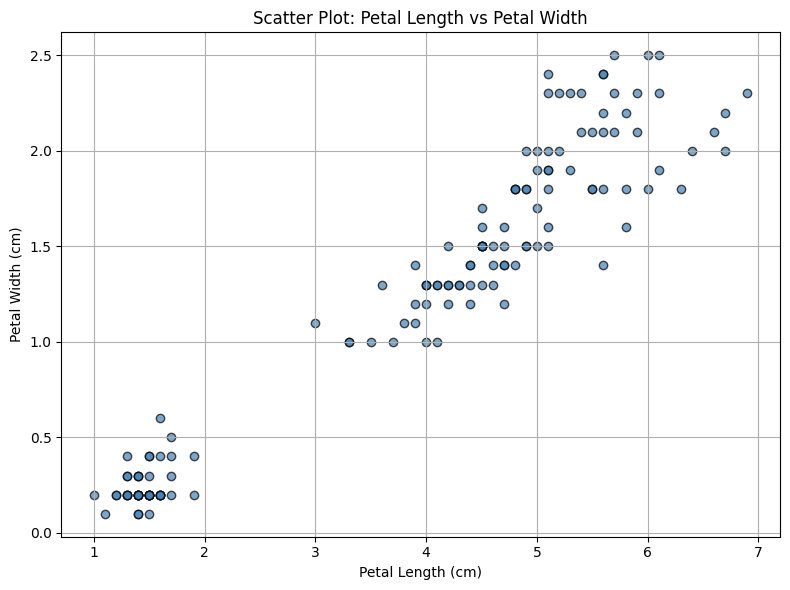

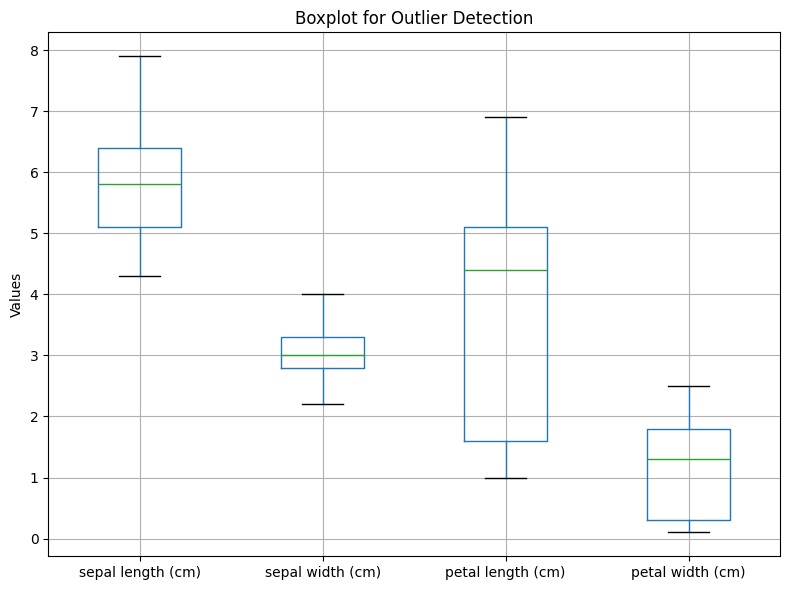

In [6]:
# 5. DATA VISUALIZATION


# Scatter Plot: Raw Data
plt.figure(figsize=(8, 6))
plt.scatter(
    data['petal length (cm)'],
    data['petal width (cm)'],
    color='steelblue',
    edgecolors='black',
    alpha=0.7
)
plt.title("Scatter Plot: Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()


# Boxplot for Outlier Detection

plt.figure(figsize=(8, 6))
data[feature_cols].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.ylabel("Values")
plt.grid(True)
plt.tight_layout()
plt.show()


ELBOW METHOD - FINDING OPTIMAL K


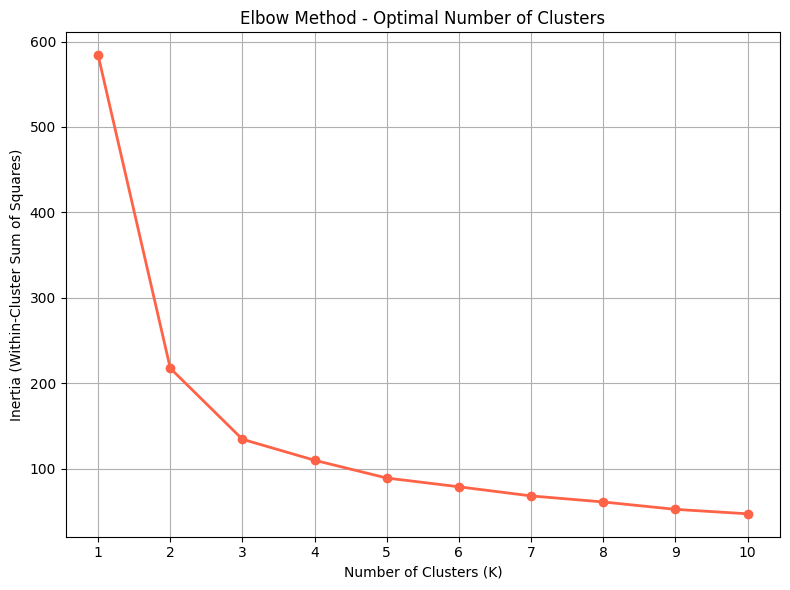

From the Elbow plot, K=3 is the optimal number of clusters.


In [7]:
# 6. ELBOW METHOD - Find Optimal Number of Clusters


print("\n=================================================")
print("ELBOW METHOD - FINDING OPTIMAL K")
print("=================================================")

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o', color='tomato', linewidth=2)
plt.title("Elbow Method - Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

print("From the Elbow plot, K=3 is the optimal number of clusters.")


K-MEANS CLUSTERING (K=3)
Cluster Labels (First 20):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


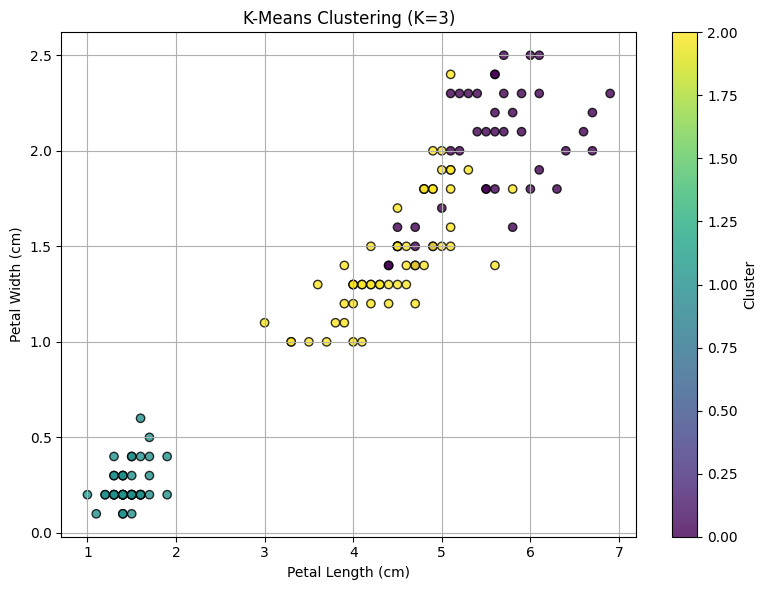

In [8]:
# 7. K-MEANS CLUSTERING


print("\n=================================================")
print("K-MEANS CLUSTERING (K=3)")
print("=================================================")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(scaled_df)

clusters = kmeans.labels_

print("Cluster Labels (First 20):")
print(clusters[:20])

# Add cluster labels to dataset
data['Cluster'] = clusters

# Cluster Visualization
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    data['petal length (cm)'],
    data['petal width (cm)'],
    c=data['Cluster'],
    cmap='viridis',
    edgecolors='black',
    alpha=0.8
)
plt.colorbar(scatter, label='Cluster')
plt.title("K-Means Clustering (K=3)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# 8. SELECT TWO DATA POINTS (from SCALED data)

A = scaled_df.iloc[0].values
B = scaled_df.iloc[1].values

print("\n=================================================")
print("SAMPLE A (Scaled) - Row 0")
print("=================================================")
print(A)

print("\n=================================================")
print("SAMPLE B (Scaled) - Row 1")
print("=================================================")
print(B)


SAMPLE A (Scaled) - Row 0
[-0.9105154   1.15915054 -1.37376391 -1.34852508]

SAMPLE B (Scaled) - Row 1
[-1.15112218 -0.10192233 -1.37376391 -1.34852508]


In [10]:
# =================================================
# 9. EUCLIDEAN DISTANCE
# Formula:
# d(x,y) = sqrt( Σ (xi - yi)^2 )
# =================================================

euclidean_distance = euclidean(A, B)

print("\n=================================================")
print("EUCLIDEAN DISTANCE")
print("=================================================")
print("Formula: d(x,y) = sqrt( Σ (xi - yi)^2 )")
print("Result :", round(euclidean_distance, 6))


EUCLIDEAN DISTANCE
Formula: d(x,y) = sqrt( Σ (xi - yi)^2 )
Result : 1.283821


In [11]:
# =========================================================
# 10. MANHATTAN DISTANCE
# Formula:
# d(x,y) = Σ |xi - yi|
# =========================================================

manhattan_distance = cityblock(A, B)

print("\n=================================================")
print("MANHATTAN DISTANCE")
print("=================================================")
print("Formula: d(x,y) = Σ |xi - yi|")
print("Result :", round(manhattan_distance, 6))


MANHATTAN DISTANCE
Formula: d(x,y) = Σ |xi - yi|
Result : 1.50168


In [12]:
# =========================================================
# 11. SUPREMUM DISTANCE (CHEBYSHEV)
# Formula:
# d(x,y) = max |xi - yi|
# =========================================================

supremum_distance = chebyshev(A, B)

print("\n=================================================")
print("SUPREMUM DISTANCE (CHEBYSHEV)")
print("=================================================")
print("Formula: d(x,y) = max |xi - yi|")
print("Result :", round(supremum_distance, 6))


SUPREMUM DISTANCE (CHEBYSHEV)
Formula: d(x,y) = max |xi - yi|
Result : 1.261073


In [13]:
# =========================================================
# 12. COSINE SIMILARITY
# Formula:
# cos(theta) = (A . B) / (||A|| ||B||)
# =========================================================

cosine_sim = cosine_similarity([A], [B])

print("\n=================================================")
print("COSINE SIMILARITY")
print("=================================================")
print("Formula: cos(theta) = (A . B) / (||A|| ||B||)")
print("Result :", round(cosine_sim[0][0], 6))



COSINE SIMILARITY
Formula: cos(theta) = (A . B) / (||A|| ||B||)
Result : 0.851568


In [14]:
# =========================================================
# 13. JACCARD SIMILARITY
# Formula:
# J(A,B) = |A ∩ B| / |A ∪ B|
# =========================================================

A_binary = np.where(A > np.mean(A), 1, 0)
B_binary = np.where(B > np.mean(B), 1, 0)

jaccard_distance = jaccard(A_binary, B_binary)
jaccard_similarity = 1 - jaccard_distance

print("\n=================================================")
print("JACCARD SIMILARITY")
print("=================================================")
print("Formula: J(A,B) = |A ∩ B| / |A ∪ B|")
print("Note: Binarized using each sample's mean as threshold.")
print("\nBinary A:", A_binary)
print("Binary B:", B_binary)
print("Result :", round(jaccard_similarity, 6))



JACCARD SIMILARITY
Formula: J(A,B) = |A ∩ B| / |A ∪ B|
Note: Binarized using each sample's mean as threshold.

Binary A: [0 1 0 0]
Binary B: [0 1 0 0]
Result : 1.0


In [15]:
# =========================================================
# 14. FINAL SUMMARY TABLE
# =========================================================

print("\n=================================================")
print("FINAL RESULTS SUMMARY")
print("=================================================")

print("Euclidean Distance      =", euclidean_distance)
print("Manhattan Distance      =", manhattan_distance)
print("Supremum Distance       =", supremum_distance)
print("Cosine Similarity       =", cosine_sim[0][0])
print("Jaccard Similarity      =", jaccard_similarity)


FINAL RESULTS SUMMARY
Euclidean Distance      = 1.2838210176521614
Manhattan Distance      = 1.5016796526325589
Supremum Distance       = 1.2610728690526891
Cosine Similarity       = 0.8515676978077571
Jaccard Similarity      = 1.0
